In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [2]:
from neural_network import NeuralNetwork

DATA_PATH = "../dataset/dataset_preprocessed.csv"

nn_model = NeuralNetwork()

df_tmp = pd.read_csv(DATA_PATH)
input_dim = df_tmp.shape[1] - 1

nn_model.build_model(
    input_dim=input_dim,
    dropout=False,
    regularize=False
)

nn_model.load_data(DATA_PATH)

feature_names = df_tmp.columns[:-1]


Epoch 01/15 | Train Acc: 71.98% | Val Acc: 74.74% | Train F1: 0.7504 | Val F1: 0.7815
Epoch 02/15 | Train Acc: 74.38% | Val Acc: 74.52% | Train F1: 0.7718 | Val F1: 0.7735
Epoch 03/15 | Train Acc: 74.48% | Val Acc: 74.65% | Train F1: 0.7734 | Val F1: 0.7741
Epoch 04/15 | Train Acc: 74.69% | Val Acc: 74.45% | Train F1: 0.7755 | Val F1: 0.7693
Epoch 05/15 | Train Acc: 74.62% | Val Acc: 74.84% | Train F1: 0.7747 | Val F1: 0.7787
Epoch 06/15 | Train Acc: 74.69% | Val Acc: 74.90% | Train F1: 0.7750 | Val F1: 0.7777
Epoch 07/15 | Train Acc: 74.76% | Val Acc: 75.00% | Train F1: 0.7758 | Val F1: 0.7778
Epoch 08/15 | Train Acc: 74.75% | Val Acc: 75.02% | Train F1: 0.7759 | Val F1: 0.7804
Epoch 09/15 | Train Acc: 74.71% | Val Acc: 74.99% | Train F1: 0.7755 | Val F1: 0.7776
Epoch 10/15 | Train Acc: 74.78% | Val Acc: 74.98% | Train F1: 0.7761 | Val F1: 0.7780
Epoch 11/15 | Train Acc: 74.74% | Val Acc: 75.03% | Train F1: 0.7757 | Val F1: 0.7786
Epoch 12/15 | Train Acc: 74.81% | Val Acc: 74.99% | Tr

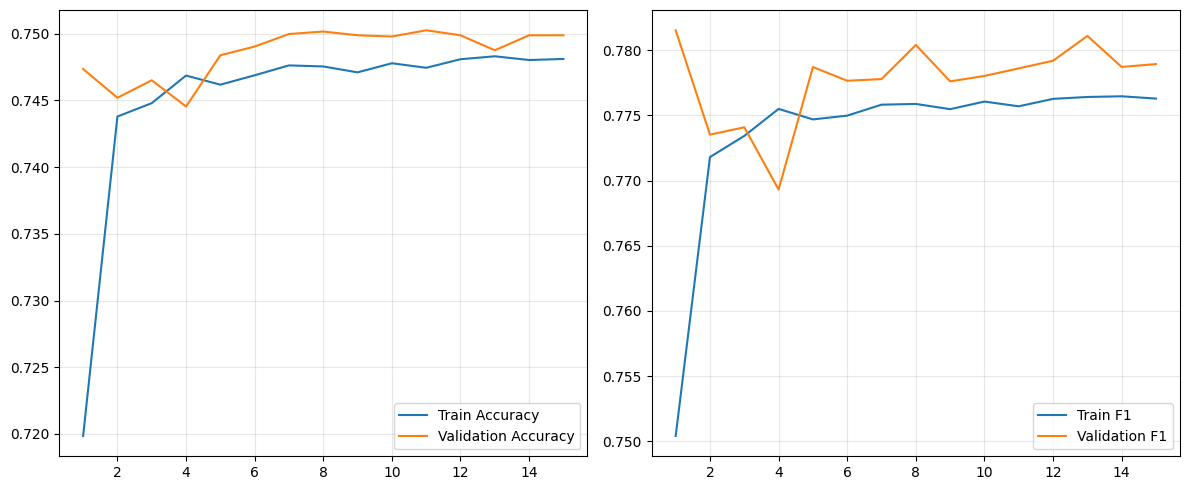

In [3]:
nn_model.train(15)

In [4]:
def get_validation_arrays(model):
    X_list, y_list = [], []

    for Xb, yb in model.val_loader:
        X_list.append(Xb)
        y_list.append(yb)

    X_val = torch.cat(X_list).cpu().numpy()
    y_val = torch.cat(y_list).cpu().numpy()

    return X_val, y_val


X_val, y_val = get_validation_arrays(nn_model)

In [5]:
def predict_f1(model, X, y, threshold=0.5):
    model.model.eval()

    with torch.no_grad():
        logits = model.model(torch.tensor(X, dtype=torch.float32))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= threshold).astype(int)

    return f1_score(y, preds, zero_division=0)

In [6]:
baseline_f1 = predict_f1(nn_model, X_val, y_val)
print(f"Baseline Validation F1: {baseline_f1:.4f}")

Baseline Validation F1: 0.7789


In [7]:
def permutation_feature_importance(
    model,
    X_val,
    y_val,
    feature_names,
    n_repeats=5,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    n_features = X_val.shape[1]

    baseline = predict_f1(model, X_val, y_val)
    importances = []

    for col in range(n_features):
        scores = []

        for _ in range(n_repeats):
            X_perm = X_val.copy()
            rng.shuffle(X_perm[:, col])

            f1 = predict_f1(model, X_perm, y_val)
            scores.append(baseline - f1)

        importances.append({
            "feature_name": feature_names[col],
            "mean_importance": np.mean(scores),
            "std_importance": np.std(scores)
        })

    return pd.DataFrame(importances).sort_values(
        by="mean_importance", ascending=False
    )

In [8]:
pfi_df = permutation_feature_importance(
    nn_model,
    X_val,
    y_val,
    feature_names,
    n_repeats=5
)


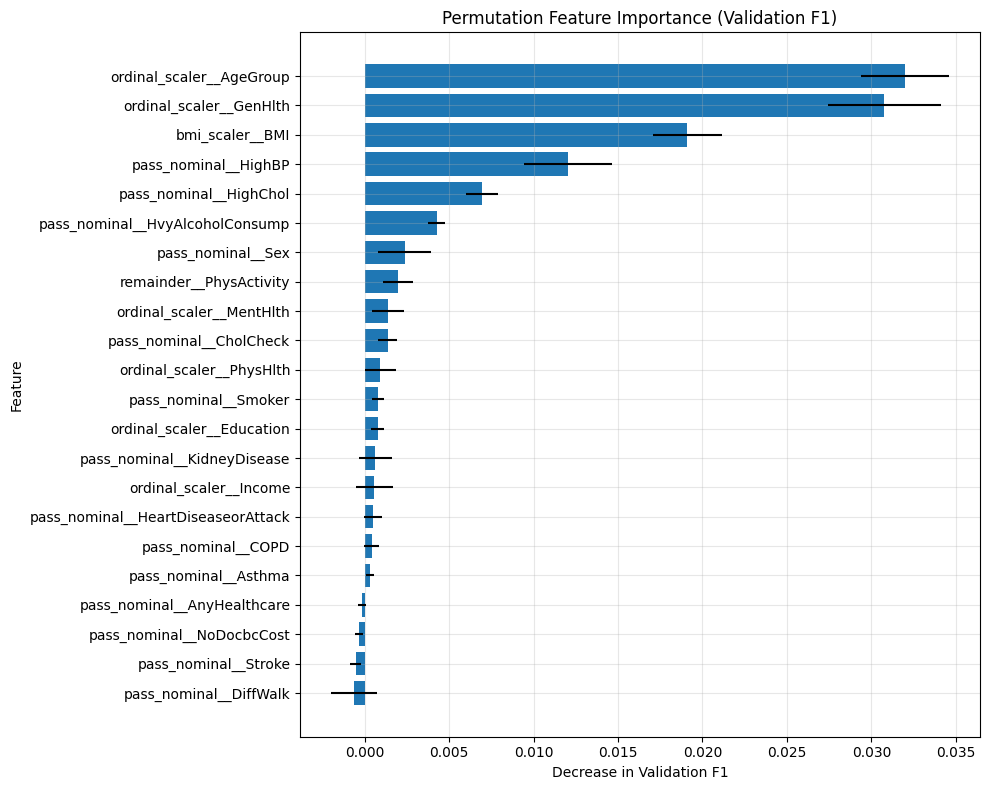

In [9]:
plt.figure(figsize=(10, 8))

plt.barh(
    pfi_df["feature_name"],
    pfi_df["mean_importance"],
    xerr=pfi_df["std_importance"]
)

plt.xlabel("Decrease in Validation F1")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Validation F1)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
